In [1]:
## Libraries needs to run the script ##
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import TPR, XTC
from MDAnalysis.analysis import density 
import numpy as np 
import matplotlib.pyplot as plt 
#import nglview as nv
from MDAnalysis import transformations as trans
%matplotlib inline

In [2]:
# Load trajectory
u = mda.Universe("equil8.tpr", ["equil7-pbc.xtc","equil8-pbc.xtc", "equil9-pbc.xtc"], in_memory=True, in_memory_step=50)

# Define atom selections
POLY = u.select_atoms('resname LIG')
EO = u.select_atoms('resname LIG and name EO')
PO = u.select_atoms('resname LIG and name PO')

In [4]:
u.trajectory

<MemoryReader with 601 frames of 62064 atoms>

In [5]:
## create the density profile for CL ##
##P = u.select_atoms('resname LIG and name C3')
dens = density.DensityAnalysis(PO,
                               delta=4.0,
                               padding=2)
dens.run()

In [6]:
import numpy as np
# ensure that the density is A^{-3}
dens.results.density.convert_density("nm^{-3}")

In [7]:
grid = dens.results.density.grid
grid.shape

(48, 54, 42)

In [8]:
mx, my, mz = dens.results.density.midpoints

In [9]:
grid = dens.results.density.grid
flat = grid.ravel() / (grid.max()*10)

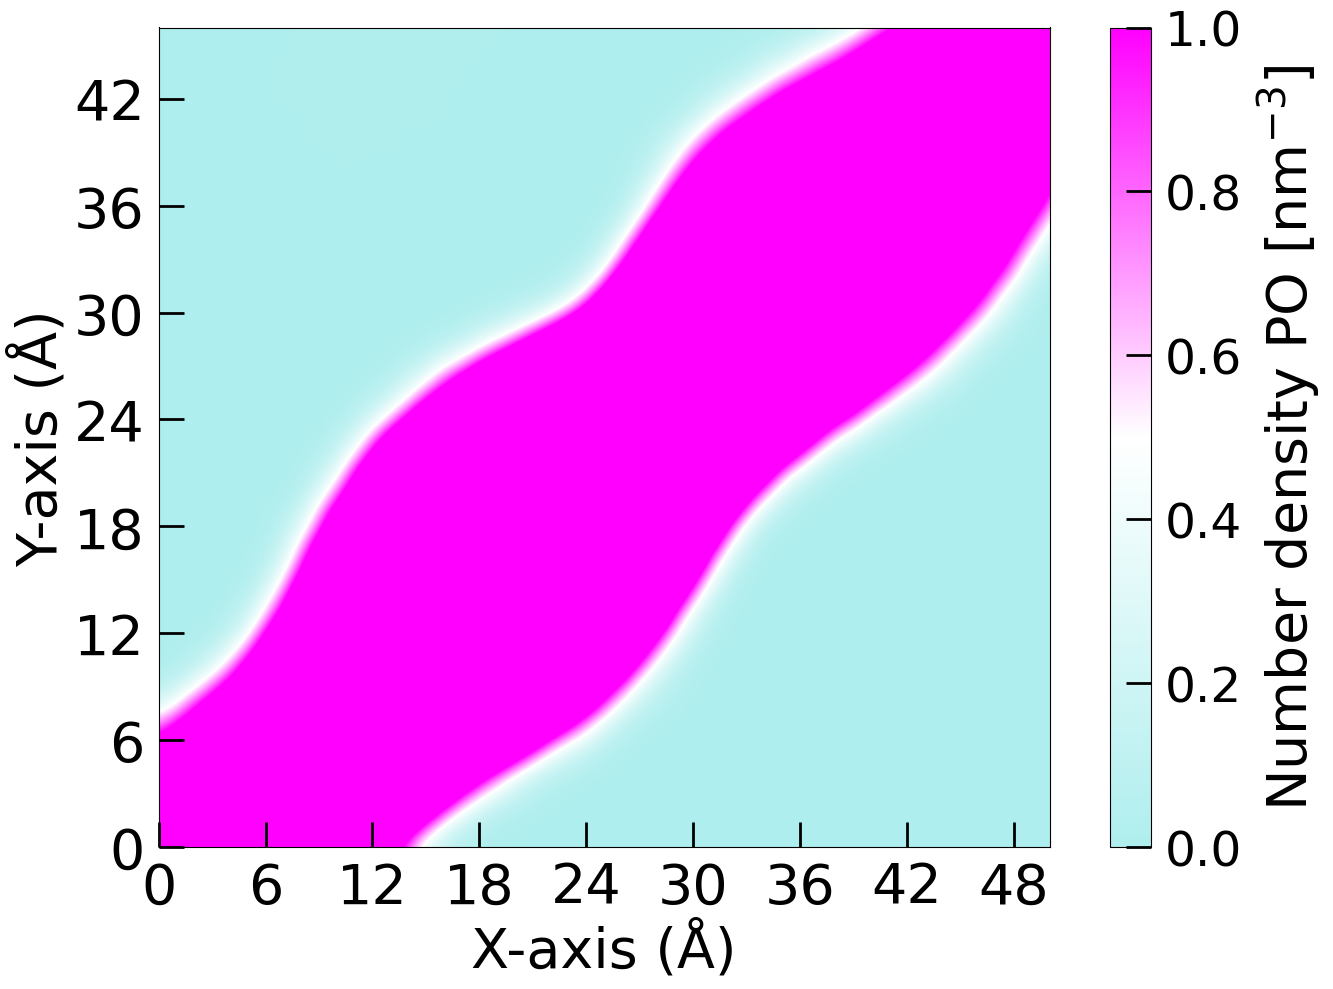

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap: blue → white → magenta
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_bwmag', ['paleturquoise', 'white', 'magenta']
)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

avg = grid.mean(axis=-1)
avg.shape
im = ax.imshow(avg, interpolation='bicubic', alpha=1, vmax=1, vmin=0, cmap=custom_cmap)
cbar = plt.colorbar(im)
cbar.set_label('Number density PO [nm$^{-3}$]', fontsize=40, fontname='DejaVu Sans', labelpad=10)

plt.xlabel('X-axis (Å)', fontsize=40, fontname='DejaVu Sans')
plt.ylabel('Y-axis (Å)', fontsize=40, fontname='DejaVu Sans')
plt.ylim(0, 46)
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50.001, 6), fontsize=40, fontname='DejaVu Sans')
plt.yticks(np.arange(0, 46.001, 6), fontsize=40, fontname='DejaVu Sans')

cbar.ax.tick_params(labelsize=35, direction='in', length=18, width=2, pad=10)
plt.tick_params(axis='both', which='major', labelsize=40, direction='in', length=18, width=2, pad=10)

plt.tight_layout()
plt.show()
fig.savefig('PO-dens-xy-new.jpg', bbox_inches='tight', dpi=500)

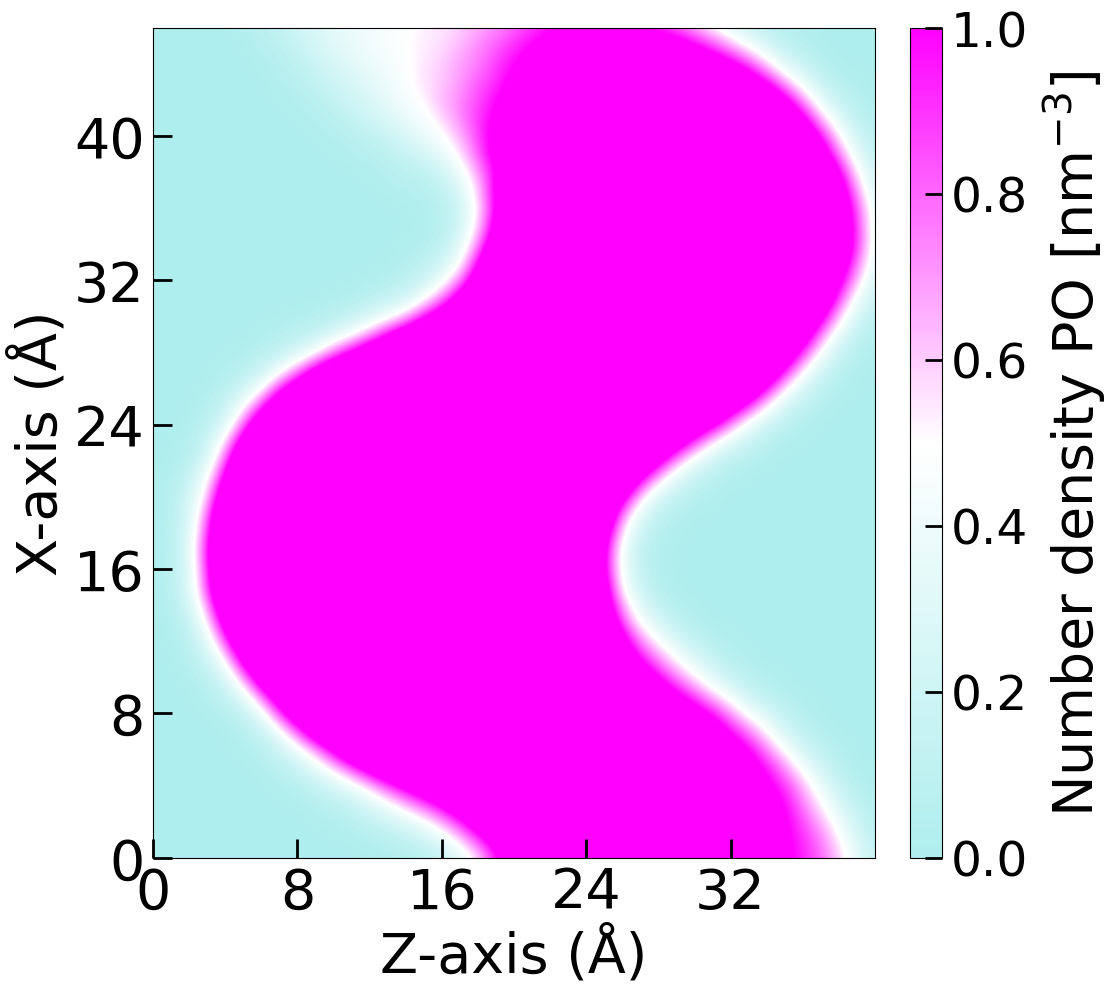

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Custom colormap: paleturquoise → white → magenta
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_bwmag', ['paleturquoise', 'white', 'magenta']
)

# Square figure, exact size
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare the data
avg = grid.mean(axis=1)

# Main plot
im = ax.imshow(avg, interpolation='bicubic', alpha=1, vmax=1, vmin=0, cmap=custom_cmap)

# Keep axes square (1:1 data units)
ax.set_aspect('equal', adjustable='box')

# Remove extra space around axes by shrinking the colorbar instead of main plot
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4.5%", pad=0.35)

# Colorbar setup
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Number density PO [nm$^{-3}$]', fontsize=40, fontname='DejaVu Sans', labelpad=10)
cbar.ax.tick_params(labelsize=35, direction='in', length=12, width=2, pad=6)

# Labels and ticks
ax.set_xlabel('Z-axis (Å)', fontsize=40, fontname='DejaVu Sans')
ax.set_ylabel('X-axis (Å)', fontsize=40, fontname='DejaVu Sans')
ax.set_xlim(0, 40)
ax.set_ylim(0, 46)
ax.set_xticks(np.arange(0, 40, 8))
ax.set_yticks(np.arange(0, 46, 8))
ax.set_xticklabels(np.arange(0, 40, 8), fontsize=40, fontname='DejaVu Sans')
ax.set_yticklabels(np.arange(0, 46, 8), fontsize=40, fontname='DejaVu Sans')

ax.tick_params(axis='both', which='major', direction='in', length=14, width=2, pad=6)

# Remove tight_layout to avoid extra margins, and manually adjust if needed
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)

# Save and show
plt.savefig('PO-dens-xz-new.jpg', bbox_inches='tight', dpi=500)
plt.show()